In [2]:
import sys
sys.path.append("D:\Internship\DTU Copenhagen (summer 2025)\PINNProof\examples\external_lib")
from external_lib.ECP.optimizers.ECP import ECP 

In [1]:
import sys
sys.path.append("D:\Internship\DTU Copenhagen (summer 2025)\PINNProof")
from external_lib.ECP.optimizers.ECP import ECP 

In [1]:
import sys
print("\n".join(sys.path))
sys.path.insert(0, "D:/Internship/DTU Copenhagen (summer 2025)/PINNProof")
print("\n".join(sys.path))

c:\Users\INDRAJIT\AppData\Local\Programs\Python\Python310\python310.zip
c:\Users\INDRAJIT\AppData\Local\Programs\Python\Python310\DLLs
c:\Users\INDRAJIT\AppData\Local\Programs\Python\Python310\lib
c:\Users\INDRAJIT\AppData\Local\Programs\Python\Python310

C:\Users\INDRAJIT\AppData\Roaming\Python\Python310\site-packages
c:\Users\INDRAJIT\AppData\Local\Programs\Python\Python310\lib\site-packages
c:\Users\INDRAJIT\AppData\Local\Programs\Python\Python310\lib\site-packages\win32
c:\Users\INDRAJIT\AppData\Local\Programs\Python\Python310\lib\site-packages\win32\lib
c:\Users\INDRAJIT\AppData\Local\Programs\Python\Python310\lib\site-packages\Pythonwin
D:/Internship/DTU Copenhagen (summer 2025)/PINNProof
c:\Users\INDRAJIT\AppData\Local\Programs\Python\Python310\python310.zip
c:\Users\INDRAJIT\AppData\Local\Programs\Python\Python310\DLLs
c:\Users\INDRAJIT\AppData\Local\Programs\Python\Python310\lib
c:\Users\INDRAJIT\AppData\Local\Programs\Python\Python310

C:\Users\INDRAJIT\AppData\Roaming\Python

In [4]:
sys.path.insert(0, '../external_lib')

In [2]:
import torch
import torch.nn as nn
from torchdiffeq import odeint_adjoint as odeint
import matplotlib.pyplot as plt

class SynchronousMachine(nn.Module):
    def __init__(self, D, P_m, X_d_dash, H, time_tensor,
                 Rs, Re, X_q_dash, Xep, Tdp, Tqp, Efd, Xd, Xq):
        super(SynchronousMachine, self).__init__()
        self.D = D
        self.P_m = P_m
        self.omega_s0 = 0.0
        self.omega_B = 2 * torch.pi * 50
        self.X_d_dash = X_d_dash
        self.H = H
        self.Rs = Rs
        self.Re = Re
        self.X_q_dash = X_q_dash
        self.Xep = Xep
        Z = torch.tensor([[self.Rs, -self.X_q_dash], [self.X_d_dash, self.Rs]])
        self.Z_inverse = torch.linalg.inv(Z)
        self.E_fd = Efd
        self.T_d_dash = Tdp
        self.T_q_dash = Tqp
        self.X_d = Xd
        self.X_q = Xq
        self.time_tensor = time_tensor
        self.V_tensor = None
        self.theta_tensor = None

    def forward(self, t, y):
        print(y.shape)
        delta, omega, E_d_dash, E_q_dash,P_m, V_t,theta_vs  = y
        # V_t = self.get_V(t)
        # theta_vs = self.get_theta(t)
        v1 = E_d_dash - V_t * torch.sin(delta - theta_vs)
        v2 = E_q_dash - V_t * torch.cos(delta - theta_vs)
        I_d = self.Z_inverse[0, 0] * v1 + self.Z_inverse[0, 1] * v2
        I_q = self.Z_inverse[1, 0] * v1 + self.Z_inverse[1, 1] * v2
        P_e = E_d_dash * I_d + E_q_dash * I_q + (self.X_q_dash - self.X_d_dash) * I_d * I_q
        ddelta_dt = omega
        domega_dt = (self.omega_B / (2 * self.H)) * (P_m - P_e - self.D * omega)
        # Internal voltages assumed constant
        dE_d = (1 / self.T_d_dash) * (- E_q_dash - I_d * (self.X_d - self.X_d_dash) + self.E_fd)
        dE_q = (1 / self.T_q_dash) * (- E_d_dash + I_q * (self.X_q - self.X_q_dash))
        dP_m = torch.tensor(0.0, dtype=y.dtype, device=y.device)
        dV_t = torch.tensor(0.0, dtype=y.dtype, device=y.device)
        d_theta_vs =torch.tensor(0.0, dtype=y.dtype, device=y.device)
        return torch.stack([ddelta_dt, domega_dt, dE_d, dE_q,dP_m, dV_t,d_theta_vs])

    def interface(self, dataset):
            Vs = dataset[:,:,-2]
            th = dataset[:,:, -1]
            delta = dataset[:,:, 0]
            omega = dataset[:,:, 1]
            E_d = dataset[:,:, 2]
            E_q = dataset[:,:, 3]

            # compute currents
            v1 = E_d - Vs * torch.sin(delta - th)
            v2 = E_q - Vs * torch.cos(delta - th)
            I_d = self.Z_inverse[0, 0] * v1 + self.Z_inverse[0, 1] * v2
            I_q = self.Z_inverse[1, 0] * v1 + self.Z_inverse[1, 1] * v2
            I_D = I_d * torch.cos(delta - torch.pi/2) - I_q * torch.sin(delta - torch.pi/2)
            I_Q = I_d * torch.sin(delta - torch.pi/2) + I_q * torch.cos(delta - torch.pi/2)
            return I_D, I_Q

torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Si

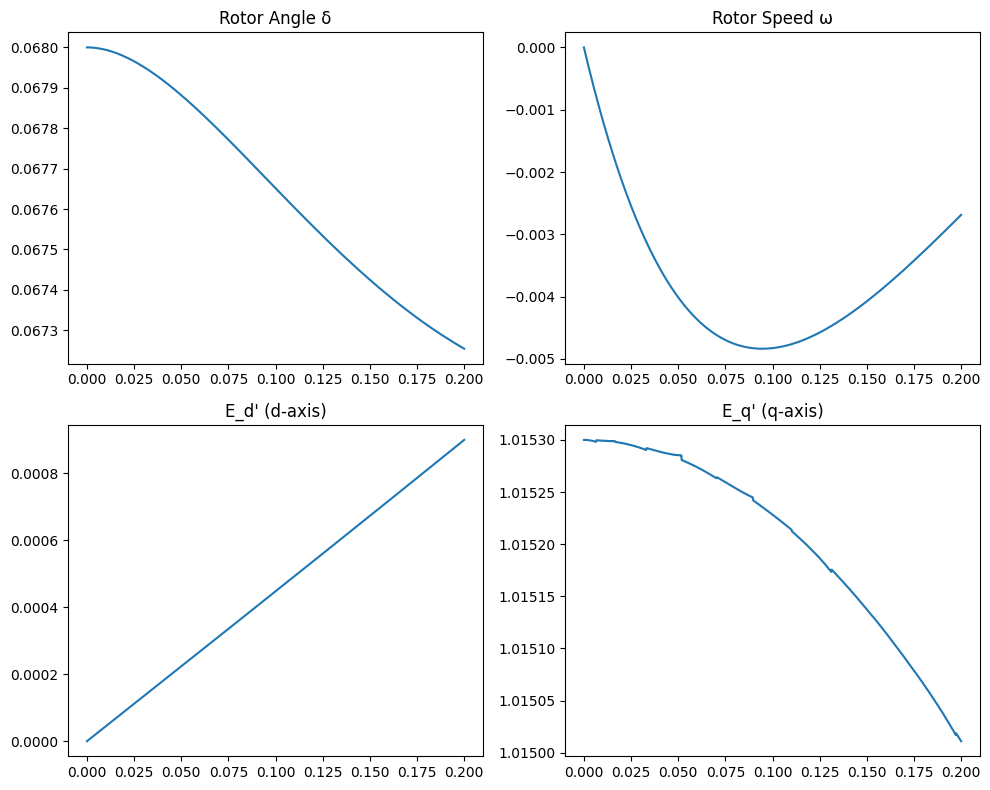

In [3]:
import torch
from torchdiffeq import odeint
from src.solvers.solver import Solver  # your base classes
from src.solvers.ODE_conventional import ODE_conventional
# from your_module import SynchronousMachine   # wherever you defined it

# 1) Create a time‐vector and a corresponding “voltage profile” for the machine.
#    Here we just hold Vs = 1.0∠0° constant.
t_final, num_points = 0.2, 1000
t_tensor = torch.linspace(0., t_final, num_points)
Vs      = torch.ones(num_points)     # pu magnitude
θs      = torch.zeros(num_points)   # pu angle
V_profile = torch.stack((Vs, θs), dim=1)  # shape (num_points, 2)

# 2) Instantiate the machine with your chosen parameters.
#    SynchronousMachine.forward has signature (t, y) → dy/dt,
#    but it needs access to V_profile and t_tensor internally.
params = {
    'D': 2.364, 'P_m': 0.71, 'X_d_dash': 0.0608, 'H': 23.64,
    'Rs': 0.0, 'Re': 0.0, 'X_q_dash': 0.0969, 'Xep': 0.0,
    'Tdp': 8.96, 'Tqp': 0.31, 'Efd': 1.08, 'Xd': 0.146, 'Xq': 0.0969
}
machine = SynchronousMachine(
    params['D'], params['P_m'], params['X_d_dash'], params['H'],
    t_tensor, params['Rs'], params['Re'], params['X_q_dash'], params['Xep'],
    params['Tdp'], params['Tqp'], params['Efd'], params['Xd'], params['Xq']
)
# machine.set_time_tensor(t_tensor)
# machine.set_V_tensor(V_profile)  # (T,1,2) as your Generator4D expects

# 3) Wrap its `forward` as the ODE‐function for your solver.
#    No extra args needed since everything is on `machine` itself
solver = ODE_conventional(machine.forward, machine.interface) 

# 4) Pick an initial state [δ₀, ω₀, E′d₀, E′q₀]
x0 = [0.0680, 0.0, 0.0, 1.0153,0.7, 1,0]

# 5) Solve!
t, sol = solver.solve(x0, t_final, num_points)
delta = sol[:,0]; omega = sol[:,1]
E_d = sol[:,2]; E_q = sol[:,3]

# plot all states & currents
fig, axs = plt.subplots(2,2,figsize=(10,8))
axs = axs.flatten()
axs[0].plot(t.squeeze(), delta.detach()); axs[0].set_title('Rotor Angle δ')
axs[1].plot(t.squeeze(), omega.detach()); axs[1].set_title('Rotor Speed ω')
axs[2].plot(t.squeeze(), E_d.detach()); axs[2].set_title("E_d' (d-axis)")
axs[3].plot(t.squeeze(), E_q.detach()); axs[3].set_title("E_q' (q-axis)")
# axs[4].plot(t.squeeze(), I_D.detach()); axs[4].set_title('Current I_D')
# axs[5].plot(t.squeeze(), I_Q.detach()); axs[5].set_title('Current I_Q')
plt.tight_layout()
# # plt.show()
# # 6) Extract and plot
# fig, axs = plt.subplots(2, 2, figsize=(12, 10))
# axs = axs.flatten()
# labels = ['δ', 'ω', "E_d'", "E_q'", "E_q''", "E_d''", 'I_D', 'I_Q']
# for i in range(4):
#     axs[i].plot(t.squeeze(), sol[:, i].detach())
#     axs[i].set_ylabel(labels[i])
# # axs[6].plot(time_pts.squeeze(), I_D.detach()); axs[6].set_ylabel('I_D')
# # axs[7].plot(time_pts.squeeze(), I_Q.detach()); axs[7].set_ylabel('I_Q')
# for ax in axs:
#     ax.set_xlabel('Time [s]')
# plt.tight_layout()
# plt.show()


In [4]:
V_profile.shape

torch.Size([1000, 2])

In [4]:
# ic_ranges = {
#   'delta': (-0.1, 0.1),
#   'omega': (-0.2, 0.2),
#   'E_d_dash': (0.0, 0.1),
#   'E_q_dash': (0.9, 1.1),
#   'V_t': (0.9, 1.1),
#   'theta_vs': (0.9, 1.1),
# }
ic_ranges = {
  'delta': (-0.5, 0.5),
  'omega': (-0.5, 0.5),
  'E_d_dash': (0.0, 0.0),
  'E_q_dash': (0.975, 1.025),
  'P_m': (0.7,0.7),
  'V_t': (0.975, 1.025),
  'theta_vs': (-0.1, 0.1),
}

t, data, ics = solver.generate_dataset(
    ic_ranges=ic_ranges,
    num_ic=100,
    t_final=t_final,
    num_points=num_points
    # save_path='datasets/sync_machine.npz'
)

D:\Internship/DTU Copenhagen (summer 2025)/PINNProof\src\solvers\ODE_conventional.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ini_cond = torch.tensor(ini_cond, dtype=torch.float32)


torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Si

In [9]:
from src.verification.utils import *

In [10]:
# For Petros' method
ic_ranges_tensor = torch.tensor(list(ic_ranges.values()))
bounds_for_sampling = list(map(tuple, ic_ranges_tensor.tolist()))
samples = sampling_domain(bounds_for_sampling, 15)
print(samples.shape)

(170859375, 7)


In [11]:
# Indrajit's method
bounds_for_sampling = ic_ranges.copy()
bounds_for_sampling['t'] = (0.0, t_final)  # add the time bounds for all-in-one sampling before the lipschitz calc
samples = torch.tensor(generate_samples(bounds_for_sampling, 1500, 'random'))
print(samples.shape)

C:\Users\INDRAJIT\AppData\Local\Temp\ipykernel_21288\959645769.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  samples = torch.tensor(generate_samples(bounds_for_sampling, 1500, 'random'))


torch.Size([1500, 8])


In [12]:
bounds_for_sampling

{'delta': (-1.0, 1.0),
 'omega': (-1.0, 1.0),
 'E_d_dash': (0.0, 0.0),
 'E_q_dash': (0.95, 1.05),
 'P_m': (0.7, 0.7),
 'V_t': (0.95, 1.05),
 'theta_vs': (-0.2, 0.2),
 't': (0.0, 0.2)}

In [12]:
conventional = Conventional(solver)  # this 'solver' object being passed is already defined in the SynchronousMachine class

In [14]:
print(data.shape)
print(t.shape)
print(ics.shape)

torch.Size([100, 7, 1000])
torch.Size([1000])
torch.Size([100, 7])


In [5]:
I_D, I_Q = solver.interface(data)

In [11]:
print(I_D.shape)
print(I_Q.shape)

torch.Size([100, 7])
torch.Size([100, 7])


In [6]:
from pretrained_models.architectures import Network
import os
os.getcwd()
# Change to a new directory  
os.chdir("./PINNProof/PINNProof")  
print("After Changing:", os.getcwd())

FileNotFoundError: [WinError 3] The system cannot find the path specified: './PINNProof/PINNProof'

In [7]:
model=Network(input_size=8, hidden_size=64, output_size=4, num_layers=3,activation="tanh")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "pretrained_models/SM4_PDynamicNN_0.2s_with_data.pth"
model_data = torch.load(model_path, weights_only=True, map_location=device)
# Check if model_data contains the key 'model_state_dict'
if isinstance(model_data, dict) and 'model_state_dict' in model_data:
    state_dict = model_data['model_state_dict']
else:
    state_dict = model_data
    print(state_dict)
    print("Model state keys:", state_dict.keys())
    print("Expected model keys:", model.state_dict().keys())
model.load_state_dict(state_dict)

<All keys matched successfully>

In [8]:
class Conventional(nn.Module):
    '''Trying to utilise the already implemented ODE_conventional.py solver'''
    def __init__(self, solver_object):
        super(Conventional, self).__init__()
        self.solver_object = solver_object

    def forward(self, x):
        x = x.squeeze()
        t_final = x[0]
        x0 = x[1:]
        t, sol = self.solver_object.solve(x0, t_final, 2)
        final_output = sol[-1][:4]
        return final_output

In [12]:
from verification.verifier import verifier

example_verifier = verifier(model, model, ic_ranges)

In [13]:
ic_ranges

{'delta': (-0.1, 0.1),
 'omega': (-0.2, 0.2),
 'E_d_dash': (0.0, 0.0),
 'E_q_dash': (1.0, 1.0),
 'P_m': (0.7, 0.7),
 'V_t': (0.9, 1.1),
 'theta_vs': (0.9, 1.1)}

In [13]:
from src.verification.verifier import verifier

example_verifier_1 = verifier(model, model, ic_ranges)  # note that ic_ranges does not include 't'
example_verifier_2 = verifier(model, conventional, ic_ranges)

# Find the result of gradient attack on model vs model
G1 = example_verifier_1.gradient_attack(model, model, bounds_for_sampling, num_steps=100, learning_rate=0.01, num_restarts=10)
print(G1)
# Find the result of gradient attack on model vs conventional
G2 = example_verifier_2.gradient_attack(model, conventional, bounds_for_sampling, num_steps=100, learning_rate=0.01, num_restarts=10)
print(G2)

# Find the result of ECP on model vs model
E1 = example_verifier_1.every_call_counts(model, model, bounds_for_sampling, num_steps=100)
print(E1)
# Find the result of ECP on model vs conventional
E2 = example_verifier_2.every_call_counts(model, conventional, bounds_for_sampling, num_steps=100)
print(E2)

  Restart 1/10: New max error found: 0.000000
(0.0, tensor([0.2000, 0.5000, 0.5000, 0.0000, 1.0250, 0.7000, 1.0250, 0.1000]))
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size

In [14]:
print("G2", G2)
print("================\n")
print("E2", E2)
print("================\n")

G2 (0.02741372026503086, tensor([0.1106, 0.0491, 0.4921, 0.0000, 0.9830, 0.7000, 1.0070, 0.0954]))

E2 (1.6421972513198853, array([ 0.1434806 ,  0.49835509,  0.38958975,  0.        ,  1.021386  ,
        0.7       ,  0.98361714, -0.07890364]))



In [15]:
print("model(G2): ")
print(model(G2[1]))
print("================\n")
print("solver(G2): ")
print(conventional(G2[1]))
print("================\n")
print("model(E2): ")
print(model(torch.tensor(E2[1], dtype=torch.float32)))
print("================\n")
print("solver(E2): ")
print(conventional(torch.tensor(E2[1], dtype=torch.float32)))


model(G2): 
tensor([ 9.2531e-02,  3.5521e-01, -9.5536e-04,  9.8465e-01],
       grad_fn=<ViewBackward0>)

solver(G2): 
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
tensor([0.0989, 0.3817, 0.0016, 0.9827])

model(E2): 
tensor([ 0.4966, -0.0531,  0.0289,  1.0038], grad_fn=<ViewBackward0>)

solver(E2): 
torch.Size([7])
torch.Size([7])
torch.S

In [18]:
G2

(1.6014211177825928,
 tensor([0.2000, 0.1000, 0.2000, 0.0000, 1.0000, 0.7000, 1.0012, 0.9000]))

In [20]:
conventional(G2[1])

torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Si

D:\Internship/DTU Copenhagen (summer 2025)/PINNProof\src\solvers\ODE_conventional.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ini_cond = torch.tensor(ini_cond, dtype=torch.float32)


tensor([ 0.5627,  2.3410, -0.0039,  1.0017])

In [17]:
model(torch.tensor(E2[1], dtype=torch.float32))

tensor([ 0.0321,  1.2123, -0.0342,  0.9845], grad_fn=<ViewBackward0>)

In [15]:
L = example_verifier(model, model, bounds_for_sampling)

KeyError: 't'

In [16]:
G = example_verifier.gradient_attack(model, model, bounds_for_sampling, num_steps=100, learning_rate=0.01, num_restarts=10)

  Restart 1/10: New max error found: 0.000000


In [13]:
E = example_verifier.every_call_counts(model, model, bounds_for_sampling, num_steps=100)

In [14]:
print(E)

(0.0, array([ 0.03080005, -0.08051305,  0.        ,  1.        ,  0.7       ,
        1.05340311,  0.97646841,  0.11229288]))


In [17]:
from solvers.solver_nn import Solver_NN
import numpy as np

In [ ]:
class optimisation_function_ECP:

    def __init__(self, model1, model2, bounds) -> None:
        self.bounds = np.array(list(bounds.values()))
        self.dimensions = len(bounds)  # should be the total number of input variables
        self.model1 = model1
        self.model2 = model2

    def __call__(self, x: np.ndarray = None) -> float:
        # if x is not None:
        #     # Handle input as a numpy array
        #     if len(x) != self.dimensions:
        #         raise ValueError(f"Input must have {self.dimensions} dimensions.")

        # Function
        # reward = 20 * np.exp(-0.2 * np.sqrt(0.5 * ((x[0] + 1) ** 2 + (x[1] + 1) ** 2))) + np.exp(
        #     0.5 * (np.cos(2 * np.pi * (x[0] + 1)) + np.cos(2 * np.pi * (x[1] + 1)))) - np.exp(1) - 20
        
        out1 = self.model1(torch.tensor(x, dtype=torch.float32))
        out2 = self.model2(torch.tensor(x, dtype=torch.float32))
        reward = torch.norm(out1 - out2).item()

        return reward

In [32]:
f = optimisation_function_ECP(model, model, 8, bounds_for_sampling)  # note that bounds_for_sampling has t at the end, for now this is just to check if the function works
points, values, epsilons = ECP(f, n=100)

print("best point ", points[np.argmax(values)])
print("max ", max(values))

best point  [ 0.08921592 -0.07930357  0.          1.          0.7         1.07980008
  1.04667885  0.06043402]
max  0.0


In [15]:
sample_solver_nn = Solver_NN(func=machine.forward, n_control=3, n_states=4, model=model)

In [16]:
t, Y = sample_solver_nn.solve(ini_cond=[0.2, 0.3, -0.4, 0.1, 0.0, 0.6, 0.8], t_final=2.0, num_points=100)

In [18]:
Y.shape

(100, 4)

In [17]:
R = sample_solver_nn.compute_residuals(bounds_for_sampling, 9, 100)

torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Si

In [19]:
R.shape

torch.Size([9, 100, 4])

In [7]:
from ECP.optimizers.ECP import ECP

ModuleNotFoundError: No module named 'utils'